In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.5.1


In [5]:
# Load the IMDB movie review dataset

NUM_WORDS = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=NUM_WORDS
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("First review sequence:", X_train[0][:20])
print("First review label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training samples: 25000
Testing samples: 25000
First review sequence: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
First review label: 1


In [6]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nClass distribution:")
print("Negative reviews (0):", np.sum(y_train == 0))
print("Positive reviews (1):", np.sum(y_train == 1))

print("\nFirst 5 labels:", y_train[:5])

print("\nReview length statistics:")
print("Minimum length:", min(len(x) for x in X_train))
print("Maximum length:", max(len(x) for x in X_train))
print("Average length:", np.mean([len(x) for x in X_train]))

Training data shape: (25000,)
Testing data shape: (25000,)

Class distribution:
Negative reviews (0): 12500
Positive reviews (1): 12500

First 5 labels: [1 0 0 1 0]

Review length statistics:
Minimum length: 11
Maximum length: 2494
Average length: 238.71364


In [7]:
# Set maximum sequence length
MAX_LEN = 200

# Pad and truncate training sequences
X_train_pad = pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

# Pad and truncate testing sequences
X_test_pad = pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print("Training data shape after padding:", X_train_pad.shape)
print("Testing data shape after padding:", X_test_pad.shape)

Training data shape after padding: (25000, 200)
Testing data shape after padding: (25000, 200)


In [9]:
# Rebuild RNN model with explicit input shape

rnn_model = Sequential([
    tf.keras.Input(shape=(200,)),
    Embedding(input_dim=10000, output_dim=64),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the RNN model

start_time = time.time()

rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

rnn_training_time = time.time() - start_time

print(f"\nRNN Training Time: {rnn_training_time:.2f} seconds")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 203ms/step - accuracy: 0.4967 - loss: 0.6953 - val_accuracy: 0.5006 - val_loss: 0.6936
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - accuracy: 0.5957 - loss: 0.6591 - val_accuracy: 0.5036 - val_loss: 0.7085
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 184ms/step - accuracy: 0.6963 - loss: 0.5202 - val_accuracy: 0.5044 - val_loss: 0.8105
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 209ms/step - accuracy: 0.7455 - loss: 0.3987 - val_accuracy: 0.4980 - val_loss: 0.9191
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 210ms/step - accuracy: 0.7713 - loss: 0.3514 - val_accuracy: 0.5154 - val_loss: 0.9875

RNN Training Time: 179.54 seconds


In [11]:
# Evaluate RNN on test data

rnn_test_loss, rnn_test_accuracy = rnn_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print(f"RNN Test Loss: {rnn_test_loss:.4f}")
print(f"RNN Test Accuracy: {rnn_test_accuracy:.4f}")

RNN Test Loss: 0.9990
RNN Test Accuracy: 0.5088


In [12]:
# Build LSTM model

lstm_model = Sequential([
    tf.keras.Input(shape=(200,)),
    Embedding(input_dim=10000, output_dim=64),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train the LSTM model

start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

lstm_training_time = time.time() - start_time

print(f"\nLSTM Training Time: {lstm_training_time:.2f} seconds")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 85s 535ms/step - accuracy: 0.5293 - loss: 0.6913 - val_accuracy: 0.5740 - val_loss: 0.6749
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 448ms/step - accuracy: 0.5532 - loss: 0.6797 - val_accuracy: 0.7248 - val_loss: 0.6240
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 389ms/step - accuracy: 0.5563 - loss: 0.7019 - val_accuracy: 0.5728 - val_loss: 0.6848
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 455ms/step - accuracy: 0.5767 - loss: 0.6779 - val_accuracy: 0.5486 - val_loss: 0.6758
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 86s 479ms/step - accuracy: 0.6033 - loss: 0.6571 - val_accuracy: 0.5196 - val_loss: 0.6917

LSTM Training Time: 373.79 seconds


In [14]:
# Evaluate LSTM on test data

lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print(f"LSTM Test Loss: {lstm_test_loss:.4f}")
print(f"LSTM Test Accuracy: {lstm_test_accuracy:.4f}")

LSTM Test Loss: 0.6907
LSTM Test Accuracy: 0.5131


In [15]:
# Build GRU model

gru_model = Sequential([
    tf.keras.Input(shape=(200,)),
    Embedding(input_dim=10000, output_dim=64),
    GRU(64),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,025 (2.54 MB)

 Trainable params: 665,025 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train the GRU model

start_time = time.time()

gru_history = gru_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

gru_training_time = time.time() - start_time

print(f"\nGRU Training Time: {gru_training_time:.2f} seconds")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 74s 449ms/step - accuracy: 0.5110 - loss: 0.6923 - val_accuracy: 0.5428 - val_loss: 0.6895
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 73s 464ms/step - accuracy: 0.5627 - loss: 0.7117 - val_accuracy: 0.5266 - val_loss: 0.6899
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 525ms/step - accuracy: 0.6114 - loss: 0.6552 - val_accuracy: 0.6650 - val_loss: 0.6343
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 78s 495ms/step - accuracy: 0.8166 - loss: 0.4296 - val_accuracy: 0.8310 - val_loss: 0.4017
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 78s 497ms/step - accuracy: 0.8904 - loss: 0.2815 - val_accuracy: 0.8466 - val_loss: 0.3613

GRU Training Time: 385.69 seconds


In [17]:
# Evaluate GRU on test data

gru_test_loss, gru_test_accuracy = gru_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print(f"GRU Test Loss: {gru_test_loss:.4f}")
print(f"GRU Test Accuracy: {gru_test_accuracy:.4f}")

GRU Test Loss: 0.3823
GRU Test Accuracy: 0.8344


In [18]:
# Generate predictions for all three models

rnn_pred_prob = rnn_model.predict(X_test_pad, verbose=0)
lstm_pred_prob = lstm_model.predict(X_test_pad, verbose=0)
gru_pred_prob = gru_model.predict(X_test_pad, verbose=0)

# Convert probabilities into class predictions
rnn_pred = (rnn_pred_prob >= 0.5).astype(int).flatten()
lstm_pred = (lstm_pred_prob >= 0.5).astype(int).flatten()
gru_pred = (gru_pred_prob >= 0.5).astype(int).flatten()

print("Predictions generated successfully.")
print("RNN predictions:", rnn_pred[:10])
print("LSTM predictions:", lstm_pred[:10])
print("GRU predictions:", gru_pred[:10])

Predictions generated successfully.
RNN predictions: [1 0 1 1 1 1 0 0 0 1]
LSTM predictions: [0 1 1 0 0 0 1 0 0 1]
GRU predictions: [0 1 1 0 1 1 0 0 1 1]


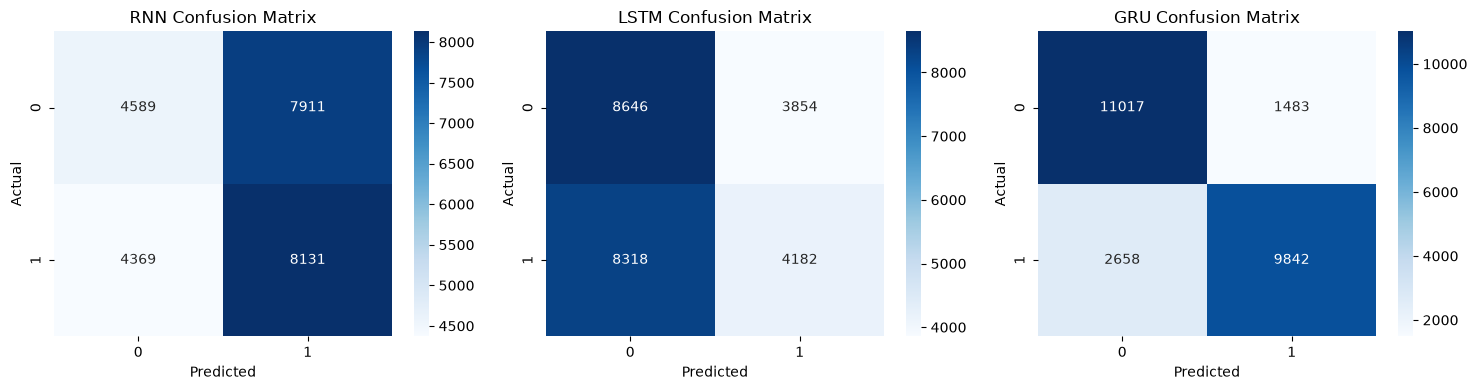

In [20]:
# Generate confusion matrices

rnn_cm = confusion_matrix(y_test, rnn_pred)
lstm_cm = confusion_matrix(y_test, lstm_pred)
gru_cm = confusion_matrix(y_test, gru_pred)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(rnn_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('RNN Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('LSTM Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(gru_cm, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('GRU Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

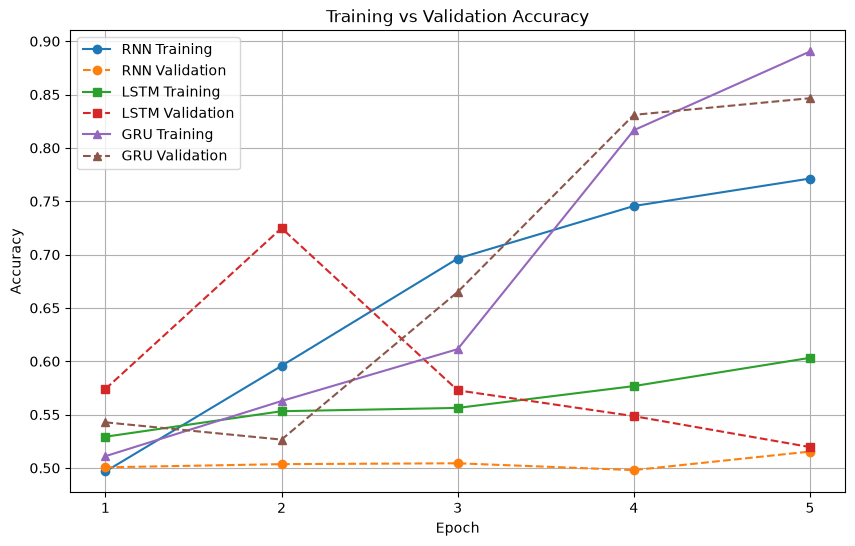

In [21]:
# Compare training and validation accuracy

plt.figure(figsize=(10, 6))

plt.plot(rnn_history.history['accuracy'], marker='o', label='RNN Training')
plt.plot(rnn_history.history['val_accuracy'], marker='o', linestyle='--', label='RNN Validation')

plt.plot(lstm_history.history['accuracy'], marker='s', label='LSTM Training')
plt.plot(lstm_history.history['val_accuracy'], marker='s', linestyle='--', label='LSTM Validation')

plt.plot(gru_history.history['accuracy'], marker='^', label='GRU Training')
plt.plot(gru_history.history['val_accuracy'], marker='^', linestyle='--', label='GRU Validation')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(5), range(1, 6))
plt.legend()
plt.grid(True)
plt.show()

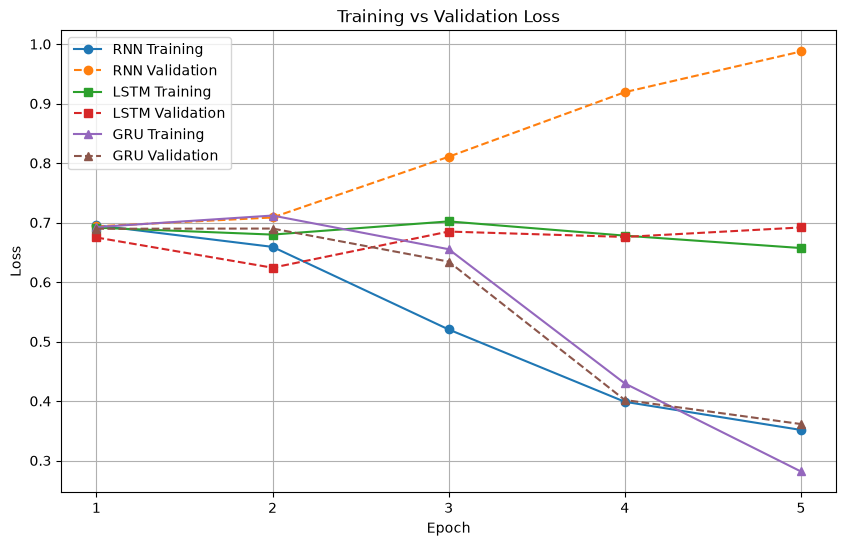

In [22]:
# Compare training and validation loss

plt.figure(figsize=(10, 6))

plt.plot(rnn_history.history['loss'], marker='o', label='RNN Training')
plt.plot(rnn_history.history['val_loss'], marker='o', linestyle='--', label='RNN Validation')

plt.plot(lstm_history.history['loss'], marker='s', label='LSTM Training')
plt.plot(lstm_history.history['val_loss'], marker='s', linestyle='--', label='LSTM Validation')

plt.plot(gru_history.history['loss'], marker='^', label='GRU Training')
plt.plot(gru_history.history['val_loss'], marker='^', linestyle='--', label='GRU Validation')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(5), range(1, 6))
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# Create final performance comparison table

final_comparison = results_df.copy()

final_comparison["Training Time (s)"] = [
    rnn_training_time,
    lstm_training_time,
    gru_training_time
]

final_comparison["Parameters"] = [
    rnn_model.count_params(),
    lstm_model.count_params(),
    gru_model.count_params()
]

final_comparison = final_comparison[
    [
        "Model",
        "Parameters",
        "Training Time (s)",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
]

print(final_comparison.round(4).to_string(index=False))

Model  Parameters  Training Time (s)  Accuracy  Precision  Recall  F1-Score
  RNN      648321           179.5443    0.5088     0.5069  0.6505    0.5698
 LSTM      673089           373.7924    0.5131     0.5204  0.3346    0.4073
  GRU      665025           385.6863    0.8344     0.8691  0.7874    0.8262
